In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    break

/kaggle/input/chest-xray-pneumonia


In [ ]:
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir   = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir  = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    if len(files) > 0:
        print("Files:", files[:5])
    print("-"*50)

/kaggle/input/chest-xray-pneumonia
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
Files: ['.DS_Store']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
Files: ['.DS_Store']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
Files: ['person1947_bacteria_4876.jpeg', 'person1946_bacteria_4875.jpeg', 'person1952_bacteria_4883.jpeg', 'person1954_bacteria_4886.jpeg', 'person1951_bacteria_4882.jpeg']
--------------------------------------------------
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
Files: ['NORMAL2-IM-1431-0001.jpeg', 'NORMAL2-IM-1440-0001.jpeg', 'NORMAL2-IM-1442-0001.jpeg', 'NORMAL2-IM-1427-0001.jpeg', 'NORMAL2-IM-1430-0001.jpeg']
---------------------------------------

In [ ]:
def count_images(folder):
    total = 0
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            total += len(os.listdir(cls_path))
    return total

print("Train:", count_images(train_dir))
print("Validation:", count_images(val_dir))
print("Test:", count_images(test_dir))

Train: 5216
Validation: 16
Test: 624


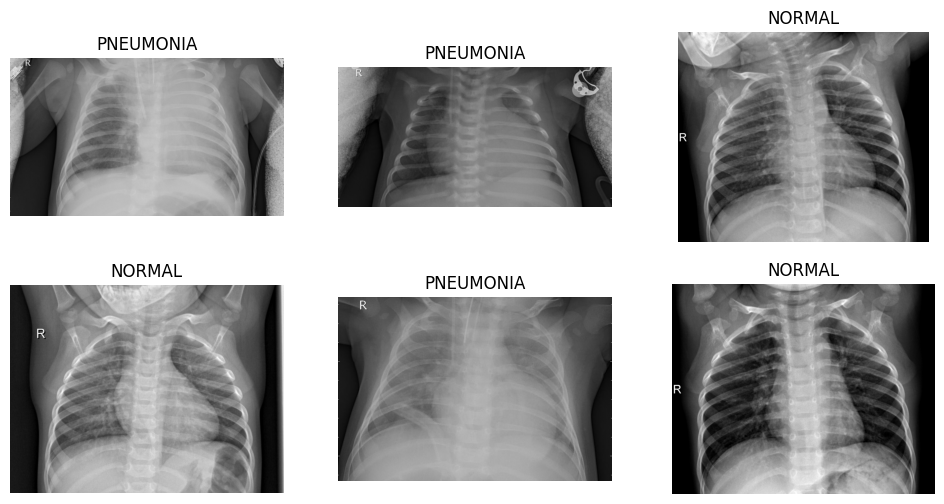

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

classes = ['NORMAL','PNEUMONIA']

plt.figure(figsize=(12,6))

for i in range(6):

    cls=random.choice(classes)

    img_path=os.path.join(
        train_dir,
        cls,
        random.choice(os.listdir(os.path.join(train_dir,cls)))
    )

    img=Image.open(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(cls)
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

cnn_model = Sequential()

cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

cnn_model.add(MaxPooling2D())

cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D())

cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(MaxPooling2D())

cnn_model.add(Flatten())

cnn_model.add(Dense(128,activation='relu'))

cnn_model.add(Dropout(0.5))

cnn_model.add(Dense(1,activation='sigmoid'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
import time

start=time.time()

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

cnn_time=time.time()-start

print("CNN Training Time:",cnn_time)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 639s 4s/step - accuracy: 0.8031 - loss: 0.4430 - val_accuracy: 0.6875 - val_loss: 0.5611
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 621s 4s/step - accuracy: 0.8746 - loss: 0.2855 - val_accuracy: 0.6875 - val_loss: 0.6286
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 601s 4s/step - accuracy: 0.8806 - loss: 0.2842 - val_accuracy: 0.6875 - val_loss: 0.7474
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 627s 4s/step - accuracy: 0.8946 - loss: 0.2469 - val_accuracy: 0.7500 - val_loss: 0.6394
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 621s 4s/step - accuracy: 0.8976 - loss: 0.2499 - val_accuracy: 0.6875 - val_loss: 0.8642
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 612s 4s/step - accuracy: 0.9024 - loss: 0.2260 - val_accuracy: 0.7500 - val_loss: 0.7830
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 617s 4s/step - accuracy: 0.9126 - loss: 0.2143 - val_accuracy: 0.8750 - val_loss: 0.3169
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 601s 4s/step - accuracy: 0.9132 - loss: 0.2144 - val_accu

In [ ]:
from sklearn.metrics import *

pred_prob = cnn_model.predict(test_generator)

pred = (pred_prob > 0.5).astype(int)

y_true = test_generator.classes

print(classification_report(y_true,pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
              precision    recall  f1-score   support

           0       0.90      0.77      0.83       234
           1       0.87      0.95      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624



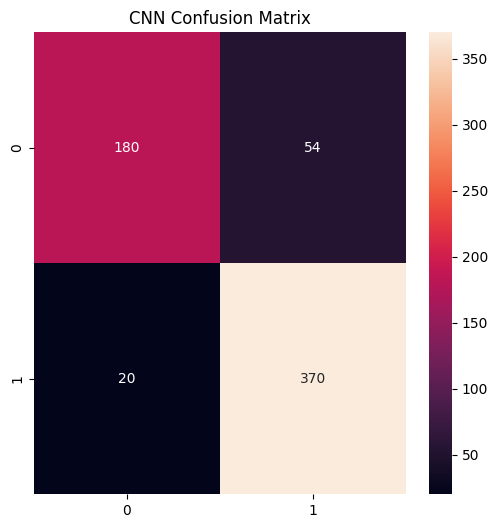

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true,pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("CNN Confusion Matrix")

plt.show()

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        1,
        activation='sigmoid'
    )

])

In [ ]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
start=time.time()

history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

mobile_time=time.time()-start

print("MobileNet Time:",mobile_time)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9041 - loss: 0.2277 - val_accuracy: 0.8125 - val_loss: 0.4849
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.9371 - loss: 0.1588 - val_accuracy: 0.8125 - val_loss: 0.4063
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.9360 - loss: 0.1510 - val_accuracy: 0.7500 - val_loss: 0.3405
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.9440 - loss: 0.1390 - val_accuracy: 0.7500 - val_loss: 0.3622
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.9440 - loss: 0.1424 - val_accuracy: 0.8125 - val_loss: 0.2806
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9463 - loss: 0.1353 - val_accuracy: 0.8125 - val_loss: 0.2619
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.9507 - loss: 0.1295 - val_accuracy: 0.8125 - val_loss: 0.2758
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.9511 - loss: 0.1211 - val_accu

In [ ]:
pred_prob_mobile = mobilenet_model.predict(
    test_generator
)

pred_mobile = (
    pred_prob_mobile > 0.5
).astype(int)

print(
    classification_report(
        y_true,
        pred_mobile
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       234
           1       0.88      0.96      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624



In [ ]:
cnn_acc = accuracy_score(
    y_true,
    pred
)

mobile_acc = accuracy_score(
    y_true,
    pred_mobile
)

import pandas as pd

results = pd.DataFrame({

    'Model':
    ['CNN','MobileNetV2'],

    'Accuracy':
    [cnn_acc,mobile_acc],

    'Training Time':
    [cnn_time,mobile_time]

})

results

,Model,Accuracy,Training Time
0,CNN,0.881410,6176.730757
1,MobileNetV2,0.897436,3161.513835


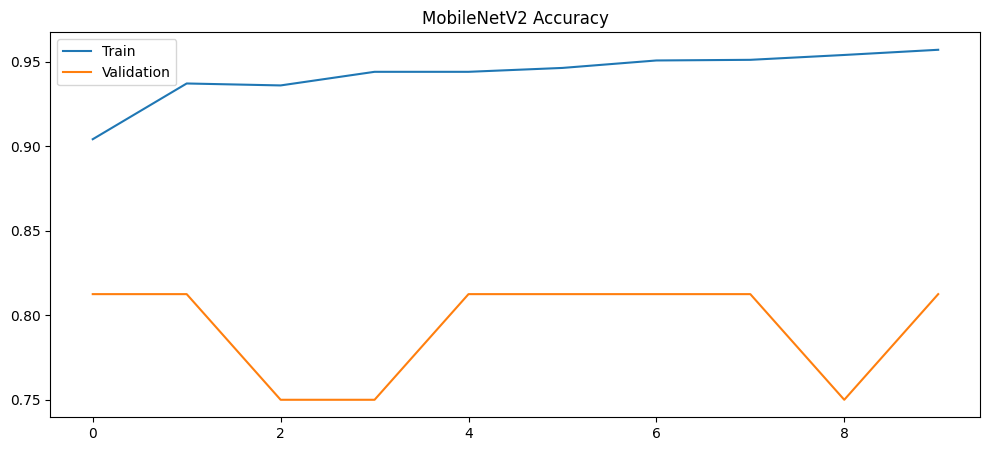

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    history_mobile.history['accuracy']
)

plt.plot(
    history_mobile.history['val_accuracy']
)

plt.legend(
    ['Train','Validation']
)

plt.title(
    "MobileNetV2 Accuracy"
)

plt.show()

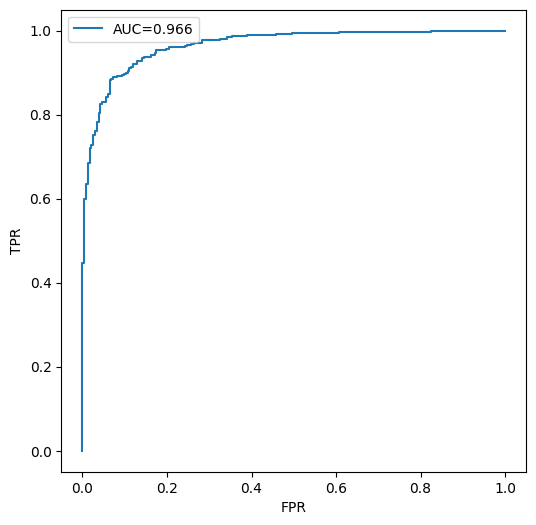

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr,tpr,_ = roc_curve(
    y_true,
    pred_prob_mobile
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={roc_auc:.3f}"
)

plt.legend()

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.show()

In [ ]:
!pip install tf-explain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00


In [ ]:
from tf_explain.core.grad_cam import GradCAM